In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


###TRANSACTIONS

In [3]:
ruta_archivo1 = '/content/drive/MyDrive/PROYECTO EQUIPO PYTHON/transactions.csv'
df1 = pd.read_csv(ruta_archivo1)
df1.head()

,transaction_id,user_id,fecha_transaccion,descripcion_transaccion,monto_transaccion,medio_pago,edad,sexo,ingreso_mensual,linea_credito,credito_utilizado,frecuencia_ahorro,categoria_gasto
0,1,1,2025-10-30,Soriana,1072.15,Debito,58,M,37256,30000,24132,Baja,Alimentacion
1,2,1,2025-04-22,Soriana,604.67,Debito,58,M,37256,30000,24132,Baja,Alimentacion
2,3,1,2025-04-12,Farmacias del Ahorro,1798.57,Transferencia,58,M,37256,30000,24132,Baja,Salud
3,4,1,2025-08-18,Uber,1485.49,Debito,58,M,37256,30000,24132,Baja,Transporte
4,5,1,2025-12-24,OXXO,1073.86,Efectivo,58,M,37256,30000,24132,Baja,Alimentacion


In [4]:
print(df1["descripcion_transaccion"].unique())
print("Cantidad:", df1["descripcion_transaccion"].nunique())

['Soriana' 'Farmacias del Ahorro' 'Uber' 'OXXO' 'Pemex' 'Amazon' 'CFE'
 'Telcel' 'DiDi' 'Spotify' 'Walmart' 'Netflix' 'Home Depot'
 'Proveedora Escolar' 'Interceramic' 'Librerías Gandhi']
Cantidad: 16


In [5]:
print(df1["medio_pago"].unique())
print("Cantidad:", df1["medio_pago"].nunique())

['Debito' 'Transferencia' 'Efectivo' 'Credito']
Cantidad: 4


In [6]:
print(df1["categoria_gasto"].unique())
print("Cantidad:", df1["categoria_gasto"].nunique())

['Alimentacion' 'Salud' 'Transporte' 'Compras' 'Servicios'
 'Entretenimiento' 'Vivienda' 'Educacion']
Cantidad: 8


In [7]:
df1 = df1.drop(["edad", "sexo", "ingreso_mensual", "linea_credito", "credito_utilizado", "frecuencia_ahorro"], axis=1)
df1.head()

,transaction_id,user_id,fecha_transaccion,descripcion_transaccion,monto_transaccion,medio_pago,categoria_gasto
0,1,1,2025-10-30,Soriana,1072.15,Debito,Alimentacion
1,2,1,2025-04-22,Soriana,604.67,Debito,Alimentacion
2,3,1,2025-04-12,Farmacias del Ahorro,1798.57,Transferencia,Salud
3,4,1,2025-08-18,Uber,1485.49,Debito,Transporte
4,5,1,2025-12-24,OXXO,1073.86,Efectivo,Alimentacion


In [8]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125465 entries, 0 to 125464
Data columns (total 7 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   transaction_id           125465 non-null  int64  
 1   user_id                  125465 non-null  int64  
 2   fecha_transaccion        125465 non-null  object 
 3   descripcion_transaccion  125465 non-null  object 
 4   monto_transaccion        125465 non-null  float64
 5   medio_pago               125465 non-null  object 
 6   categoria_gasto          125465 non-null  object 
dtypes: float64(1), int64(2), object(4)
memory usage: 6.7+ MB


In [9]:
print(df1.isnull().sum())

transaction_id             0
user_id                    0
fecha_transaccion          0
descripcion_transaccion    0
monto_transaccion          0
medio_pago                 0
categoria_gasto            0
dtype: int64


In [10]:
print("Duplicados:", df1.duplicated().sum())

Duplicados: 0


In [11]:
df1 = df1.drop_duplicates()

In [12]:
print(df1[df1["monto_transaccion"] <= 0])

Empty DataFrame
Columns: [transaction_id, user_id, fecha_transaccion, descripcion_transaccion, monto_transaccion, medio_pago, categoria_gasto]
Index: []


In [13]:
df1["descripcion_transaccion"] = df1["descripcion_transaccion"].str.strip().str.upper()
df1["medio_pago"] = df1["medio_pago"].str.strip().str.upper()
df1["categoria_gasto"] = df1["categoria_gasto"].str.strip().str.upper()
df1.head()

,transaction_id,user_id,fecha_transaccion,descripcion_transaccion,monto_transaccion,medio_pago,categoria_gasto
0,1,1,2025-10-30,SORIANA,1072.15,DEBITO,ALIMENTACION
1,2,1,2025-04-22,SORIANA,604.67,DEBITO,ALIMENTACION
2,3,1,2025-04-12,FARMACIAS DEL AHORRO,1798.57,TRANSFERENCIA,SALUD
3,4,1,2025-08-18,UBER,1485.49,DEBITO,TRANSPORTE
4,5,1,2025-12-24,OXXO,1073.86,EFECTIVO,ALIMENTACION


###USERS

In [14]:
ruta_archivo2 = '/content/drive/MyDrive/PROYECTO EQUIPO PYTHON/users.csv'
df2 = pd.read_csv(ruta_archivo2)
df2.head()

,user_id,edad,sexo,estado_civil,numero_hijos,empleo_formal,ingreso_mensual,linea_credito,credito_utilizado,frecuencia_ahorro,monto_promedio_ahorro,perfil_financiero
0,1,58,M,Soltero,2,0,37256,30000,24132,Baja,1117.68,En riesgo
1,2,31,M,Divorciado,1,1,61354,30000,3090,Baja,1840.62,En observacion
2,3,29,F,Divorciado,1,1,28866,15000,6267,Alta,6350.52,En observacion
3,4,19,F,Unión libre,3,0,69261,30000,20390,Media,6926.10,En riesgo
4,5,62,M,Divorciado,0,0,45268,80000,62746,Media,4526.80,En riesgo


In [15]:
print("Estado civil:")
print(df2["estado_civil"].unique())

Estado civil:
['Soltero' 'Divorciado' 'Unión libre' 'Casado']


In [16]:
print("perfil_financiero:")
print(df2["perfil_financiero"].unique())

perfil_financiero:
['En riesgo' 'En observacion' 'Saludable']


In [17]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                3000 non-null   int64  
 1   edad                   3000 non-null   int64  
 2   sexo                   3000 non-null   object 
 3   estado_civil           3000 non-null   object 
 4   numero_hijos           3000 non-null   int64  
 5   empleo_formal          3000 non-null   int64  
 6   ingreso_mensual        3000 non-null   int64  
 7   linea_credito          3000 non-null   int64  
 8   credito_utilizado      3000 non-null   int64  
 9   frecuencia_ahorro      3000 non-null   object 
 10  monto_promedio_ahorro  3000 non-null   float64
 11  perfil_financiero      3000 non-null   object 
dtypes: float64(1), int64(7), object(4)
memory usage: 281.4+ KB


In [18]:
print(df2.isnull().sum())

user_id                  0
edad                     0
sexo                     0
estado_civil             0
numero_hijos             0
empleo_formal            0
ingreso_mensual          0
linea_credito            0
credito_utilizado        0
frecuencia_ahorro        0
monto_promedio_ahorro    0
perfil_financiero        0
dtype: int64


In [19]:
print("Duplicados:", df2.duplicated().sum())
df2 = df2.drop_duplicates()

Duplicados: 0


In [20]:
print(df2[df2["edad"] < 18])
print(df2[df2["ingreso_mensual"] <= 0])
print(df2[df2["credito_utilizado"] > df2["linea_credito"]])

Empty DataFrame
Columns: [user_id, edad, sexo, estado_civil, numero_hijos, empleo_formal, ingreso_mensual, linea_credito, credito_utilizado, frecuencia_ahorro, monto_promedio_ahorro, perfil_financiero]
Index: []
Empty DataFrame
Columns: [user_id, edad, sexo, estado_civil, numero_hijos, empleo_formal, ingreso_mensual, linea_credito, credito_utilizado, frecuencia_ahorro, monto_promedio_ahorro, perfil_financiero]
Index: []
Empty DataFrame
Columns: [user_id, edad, sexo, estado_civil, numero_hijos, empleo_formal, ingreso_mensual, linea_credito, credito_utilizado, frecuencia_ahorro, monto_promedio_ahorro, perfil_financiero]
Index: []


In [21]:
df2["sexo"] = df2["sexo"].str.strip().str.upper()
df2["estado_civil"] = df2["estado_civil"].str.strip().str.upper()
df2["frecuencia_ahorro"] = df2["frecuencia_ahorro"].str.strip().str.upper()
df2["perfil_financiero"] = df2["perfil_financiero"].str.strip().str.upper()
df2.head()

,user_id,edad,sexo,estado_civil,numero_hijos,empleo_formal,ingreso_mensual,linea_credito,credito_utilizado,frecuencia_ahorro,monto_promedio_ahorro,perfil_financiero
0,1,58,M,SOLTERO,2,0,37256,30000,24132,BAJA,1117.68,EN RIESGO
1,2,31,M,DIVORCIADO,1,1,61354,30000,3090,BAJA,1840.62,EN OBSERVACION
2,3,29,F,DIVORCIADO,1,1,28866,15000,6267,ALTA,6350.52,EN OBSERVACION
3,4,19,F,UNIÓN LIBRE,3,0,69261,30000,20390,MEDIA,6926.10,EN RIESGO
4,5,62,M,DIVORCIADO,0,0,45268,80000,62746,MEDIA,4526.80,EN RIESGO


###Indicadores

In [22]:
dfmerge = df1.merge(df2, on="user_id", how="left")
dfmerge.head()


,transaction_id,user_id,fecha_transaccion,descripcion_transaccion,monto_transaccion,medio_pago,categoria_gasto,edad,sexo,estado_civil,numero_hijos,empleo_formal,ingreso_mensual,linea_credito,credito_utilizado,frecuencia_ahorro,monto_promedio_ahorro,perfil_financiero
0,1,1,2025-10-30,SORIANA,1072.15,DEBITO,ALIMENTACION,58,M,SOLTERO,2,0,37256,30000,24132,BAJA,1117.68,EN RIESGO
1,2,1,2025-04-22,SORIANA,604.67,DEBITO,ALIMENTACION,58,M,SOLTERO,2,0,37256,30000,24132,BAJA,1117.68,EN RIESGO
2,3,1,2025-04-12,FARMACIAS DEL AHORRO,1798.57,TRANSFERENCIA,SALUD,58,M,SOLTERO,2,0,37256,30000,24132,BAJA,1117.68,EN RIESGO
3,4,1,2025-08-18,UBER,1485.49,DEBITO,TRANSPORTE,58,M,SOLTERO,2,0,37256,30000,24132,BAJA,1117.68,EN RIESGO
4,5,1,2025-12-24,OXXO,1073.86,EFECTIVO,ALIMENTACION,58,M,SOLTERO,2,0,37256,30000,24132,BAJA,1117.68,EN RIESGO


In [23]:
print(dfmerge.isnull().sum())

transaction_id             0
user_id                    0
fecha_transaccion          0
descripcion_transaccion    0
monto_transaccion          0
medio_pago                 0
categoria_gasto            0
edad                       0
sexo                       0
estado_civil               0
numero_hijos               0
empleo_formal              0
ingreso_mensual            0
linea_credito              0
credito_utilizado          0
frecuencia_ahorro          0
monto_promedio_ahorro      0
perfil_financiero          0
dtype: int64


In [24]:
#gasto por usuario
gasto_total = dfmerge.groupby("user_id")["monto_transaccion"].sum().rename("gasto_total")
gasto_total

,gasto_total
user_id,
1,62853.25
2,59337.36
3,69448.25
4,53277.69
5,48463.69
...,...
2996,53031.36
2997,53166.41
2998,43760.80


In [25]:
# numero de transacciones por usuario
numero_transacciones = dfmerge.groupby("user_id")["monto_transaccion"].count().rename("numero_transacciones")
numero_transacciones

,numero_transacciones
user_id,
1,49
2,45
3,47
4,44
5,37
...,...
2996,43
2997,45
2998,34


In [26]:
# gasto por categoria
gasto_categoria = dfmerge.pivot_table(
    index="user_id",            # 1. ¿Quién va en las filas? Cada usuario único tendrá SU PROPIA FILA.
    columns="categoria_gasto",  # 2. ¿Qué se convierte en columnas? Cada categoría única ahora es UNA COLUMNA.
    values="monto_transaccion", # 3. ¿Qué datos vamos a mirar? El dinero de las transacciones.
    aggfunc="sum",              # 4. ¿Qué hacemos con ese dinero? Sumarlo (si hubo varios gastos en la misma categoría).
    fill_value=0                # 5. ¿Y si no gastó en algo? En vez de mostrar un vacío (NaN), pon un 0.
)
gasto_categoria.columns.name = None
gasto_categoria

,ALIMENTACION,COMPRAS,EDUCACION,ENTRETENIMIENTO,SALUD,SERVICIOS,TRANSPORTE,VIVIENDA
user_id,,,,,,,,
1,14280.40,3458.22,1318.94,1145.17,5765.65,15709.63,17986.62,3188.62
2,19324.64,0.00,1396.19,8451.10,3828.11,10104.60,11863.87,4368.85
3,9616.36,3591.74,1332.69,16494.60,7820.37,5157.98,20807.62,4626.89
4,12417.93,5204.32,587.31,8823.26,3041.88,7106.27,13226.49,2870.23
5,13815.23,4085.39,265.82,6515.99,1142.77,10458.53,11565.22,614.74
...,...,...,...,...,...,...,...,...
2996,11153.29,2217.39,964.81,11556.73,4939.95,11042.31,6227.34,4929.54
2997,7737.24,5352.24,927.39,10170.97,4705.29,8460.28,10906.37,4906.63
2998,11731.96,2427.89,258.08,4153.39,0.00,7849.88,12690.65,4648.95


In [27]:
df_indicadores = pd.concat([gasto_total, numero_transacciones, gasto_categoria], axis=1)
df_indicadores = df_indicadores.reset_index()
df_indicadores

,user_id,gasto_total,numero_transacciones,ALIMENTACION,COMPRAS,EDUCACION,ENTRETENIMIENTO,SALUD,SERVICIOS,TRANSPORTE,VIVIENDA
0,1,62853.25,49,14280.40,3458.22,1318.94,1145.17,5765.65,15709.63,17986.62,3188.62
1,2,59337.36,45,19324.64,0.00,1396.19,8451.10,3828.11,10104.60,11863.87,4368.85
2,3,69448.25,47,9616.36,3591.74,1332.69,16494.60,7820.37,5157.98,20807.62,4626.89
3,4,53277.69,44,12417.93,5204.32,587.31,8823.26,3041.88,7106.27,13226.49,2870.23
4,5,48463.69,37,13815.23,4085.39,265.82,6515.99,1142.77,10458.53,11565.22,614.74
...,...,...,...,...,...,...,...,...,...,...,...
2995,2996,53031.36,43,11153.29,2217.39,964.81,11556.73,4939.95,11042.31,6227.34,4929.54
2996,2997,53166.41,45,7737.24,5352.24,927.39,10170.97,4705.29,8460.28,10906.37,4906.63
2997,2998,43760.80,34,11731.96,2427.89,258.08,4153.39,0.00,7849.88,12690.65,4648.95
2998,2999,64736.97,51,18912.88,4301.46,351.80,7873.40,5528.83,13146.06,12556.86,2065.68


###MERGE

In [28]:
columnas = ["user_id", "ingreso_mensual", "linea_credito", "credito_utilizado","monto_promedio_ahorro", "frecuencia_ahorro", "perfil_financiero"]
df_perfil = df_indicadores.merge(df2[columnas], on="user_id", how="left")
df_perfil.head()

,user_id,gasto_total,numero_transacciones,ALIMENTACION,COMPRAS,EDUCACION,ENTRETENIMIENTO,SALUD,SERVICIOS,TRANSPORTE,VIVIENDA,ingreso_mensual,linea_credito,credito_utilizado,monto_promedio_ahorro,frecuencia_ahorro,perfil_financiero
0,1,62853.25,49,14280.40,3458.22,1318.94,1145.17,5765.65,15709.63,17986.62,3188.62,37256,30000,24132,1117.68,BAJA,EN RIESGO
1,2,59337.36,45,19324.64,0.00,1396.19,8451.10,3828.11,10104.60,11863.87,4368.85,61354,30000,3090,1840.62,BAJA,EN OBSERVACION
2,3,69448.25,47,9616.36,3591.74,1332.69,16494.60,7820.37,5157.98,20807.62,4626.89,28866,15000,6267,6350.52,ALTA,EN OBSERVACION
3,4,53277.69,44,12417.93,5204.32,587.31,8823.26,3041.88,7106.27,13226.49,2870.23,69261,30000,20390,6926.10,MEDIA,EN RIESGO
4,5,48463.69,37,13815.23,4085.39,265.82,6515.99,1142.77,10458.53,11565.22,614.74,45268,80000,62746,4526.80,MEDIA,EN RIESGO


In [29]:
df_perfil["porcentaje_gasto_ingreso"] = df_perfil["gasto_total"] / df_perfil["ingreso_mensual"]
df_perfil["porcentaje_credito_utilizado"] = df_perfil["credito_utilizado"] / df_perfil["linea_credito"]
df_perfil["porcentaje_ahorro_ingreso"] = df_perfil["monto_promedio_ahorro"] / df_perfil["ingreso_mensual"]
df_perfil.columns

Index(['user_id', 'gasto_total', 'numero_transacciones', 'ALIMENTACION',
       'COMPRAS', 'EDUCACION', 'ENTRETENIMIENTO', 'SALUD', 'SERVICIOS',
       'TRANSPORTE', 'VIVIENDA', 'ingreso_mensual', 'linea_credito',
       'credito_utilizado', 'monto_promedio_ahorro', 'frecuencia_ahorro',
       'perfil_financiero', 'porcentaje_gasto_ingreso',
       'porcentaje_credito_utilizado', 'porcentaje_ahorro_ingreso'],
      dtype='object')

In [30]:
# Cuántos usuarios hay por cada perfil
print(df_perfil["perfil_financiero"].value_counts())

perfil_financiero
EN OBSERVACION    1616
EN RIESGO         1217
SALUDABLE          167
Name: count, dtype: int64


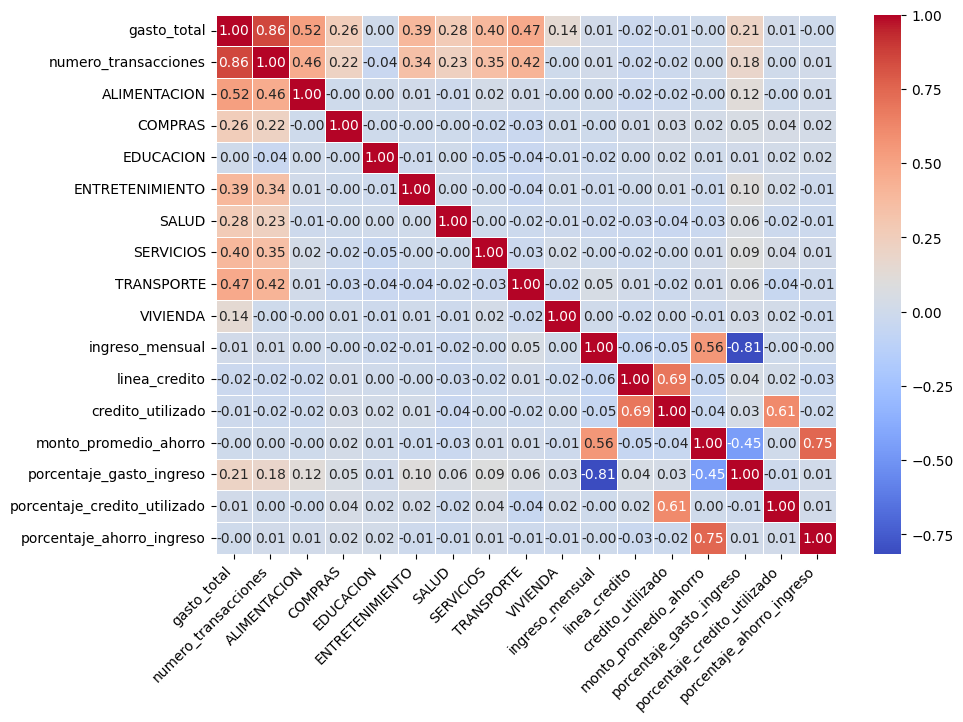

In [31]:
plt.figure(figsize=(10, 7))
df_limpio = df_perfil.select_dtypes(include="number").drop(columns=["user_id"], errors="ignore")
sns.heatmap(df_limpio.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.xticks(rotation=45, ha="right")
plt.show()